<p>Python for Civil Engineers: Plotting Shear Force & Bending Moment Diagrams</p>
<img src="https://lh3.googleusercontent.com/d/15FMDrz75pq053hM2FlKX040Ow84nS3KD" width="400" />

<p>Reaction Calculation</p>

$$
L = 4 + 8 + 6 = 18\text{ ft}
$$ 

$$
\sum M_C = 0
$$

$$
\implies R_A(12) - 900(8) - 60(18)(9-6) + 400(6) = 0
$$

$$
\boxed{R_A = 670\text{ lb}}
$$

$$
\sum F_y = 0
$$

$$
\implies R_A + R_C = 900 + 400 + (60\times18)
$$

$$
\boxed{R_C = 1710\text{ lb}}
$$


In [23]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

In [25]:
Adist = []
Asf = []
Abm = []

def sf_bm():

    # Distance & Load
    L = 18 # ft
    W = 60 # plf
    PB = 900 # lbs
    PD = 400 # lbs

    # Support Reactions
    RA = 670 # lbs
    RC = 1710 # lbs

    for i in np.linspace(0, L, L+1, dtype=int):
        Adist.append(i)

        # Shear force
        sf = RA - W*i
        if i >= 4:
            sf -= PB
        if i >= 12:
            sf += RC 
        Asf.append(sf)

        #Bending moment
        bm = RA*i - (W*i**2)/2
        if i >= 4:
            bm -= PB*(i-4)
        if i >= 12:
            bm += RC*(i-12)
        Abm.append(bm)
    return Adist, Asf, Abm
result = sf_bm()

print("Distance(x): ", Adist)
print("Shear Force(SF): ", Asf)
print("Bending Moment(BM): ", Abm)



Distance(x):  [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18)]
Shear Force(SF):  [np.int64(670), np.int64(610), np.int64(550), np.int64(490), np.int64(-470), np.int64(-530), np.int64(-590), np.int64(-650), np.int64(-710), np.int64(-770), np.int64(-830), np.int64(-890), np.int64(760), np.int64(700), np.int64(640), np.int64(580), np.int64(520), np.int64(460), np.int64(400)]
Bending Moment(BM):  [np.float64(0.0), np.float64(640.0), np.float64(1220.0), np.float64(1740.0), np.float64(2200.0), np.float64(1700.0), np.float64(1140.0), np.float64(520.0), np.float64(-160.0), np.float64(-900.0), np.float64(-1700.0), np.float64(-2560.0), np.float64(-3480.0), np.float64(-2750.0), np.float64(-2080.0), np.float64(-1470.0), np.float64(-920.0), np.float64(-430.0), np.float64(0.0)]


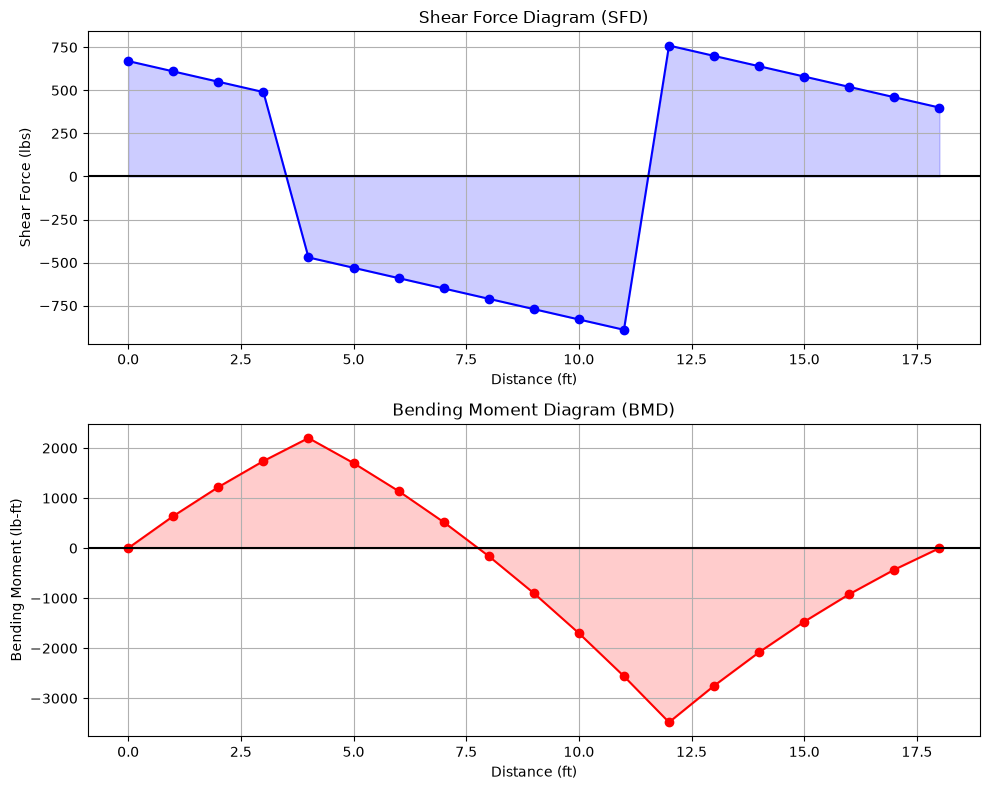

In [ ]:
plt.figure(figsize=(10,8))
plt.subplot(2,1,1)

# SFD
plt.plot(Adist, Asf, color = 'blue', marker = 'o')
plt.fill_between(Adist, Asf, 0, color = 'blue', alpha = 0.2)
plt.axhline(0, color = 'black')
plt.xlabel('Distance (ft)')
plt.ylabel('Shear Force (lbs)')
plt.title('Shear Force Diagram (SFD)')
plt.grid(True)

# BMD
plt.subplot(2,1,2)
plt.plot(Adist, Abm, color = 'red', marker = 'o')
plt.fill_between(Adist, Abm, 0, color = 'red', alpha = 0.2)
plt.axhline(0, color = 'black')
plt.xlabel('Distance (ft)')
plt.ylabel('Bending Moment (lb-ft)')
plt.title('Bending Moment Diagram (BMD)')
plt.grid(True)

plt.tight_layout()
plt.show()